# **Data Science Project - Aakansh Avasthi**

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import os
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **Load Datasets**



In [9]:
# Load Fear & Greed Index dataset
fear_greed_path = "/content/drive/MyDrive/ds_Aakansh_Avasthi/fear_greed_index.csv"

try:
    fear_greed_df = pd.read_csv(fear_greed_path)
    print(f"Fear & Greed dataset loaded: {fear_greed_df.shape}")
except Exception as e:
    print(f"Error loading Fear & Greed data: {e}")
    fear_greed_df = None

# Load Historical Trading Data
historical_path = "/content/drive/MyDrive/ds_Aakansh_Avasthi/historical_data - historical_data.csv"

try:
    historical_df = pd.read_csv(historical_path)
    print(f"Historical dataset loaded: {historical_df.shape}")
except Exception as e:
    print(f"Error loading Historical data: {e}")
    historical_df = None

Fear & Greed dataset loaded: (2644, 4)
Historical dataset loaded: (211224, 16)


In [10]:
# Explore Fear & Greed dataset
if fear_greed_df is not None:
    print("\n" + "="*60)
    print("FEAR & GREED INDEX DATASET")
    print("="*60)

    print(f"Shape: {fear_greed_df.shape}")
    print(f"Columns: {list(fear_greed_df.columns)}")

    print("\nColumn Analysis:")
    for col in fear_greed_df.columns:
        dtype = fear_greed_df[col].dtype
        unique_count = fear_greed_df[col].nunique()
        null_count = fear_greed_df[col].isnull().sum()

        print(f"{col}:")
        print(f"  Type: {dtype} | Unique: {unique_count} | Nulls: {null_count}")

        if col == 'classification':
            unique_vals = fear_greed_df[col].unique()
            print(f"  Classifications: {list(unique_vals)}")
        elif dtype in ['int64', 'float64']:
            min_val = fear_greed_df[col].min()
            max_val = fear_greed_df[col].max()
            print(f"  Range: {min_val} to {max_val}")
        elif unique_count <= 10:
            unique_vals = fear_greed_df[col].unique()
            print(f"  Values: {list(unique_vals)}")

    print("\nSample Data:")
    print(fear_greed_df.head())


FEAR & GREED INDEX DATASET
Shape: (2644, 4)
Columns: ['timestamp', 'value', 'classification', 'date']

Column Analysis:
timestamp:
  Type: int64 | Unique: 2644 | Nulls: 0
  Range: 1517463000 to 1746163800
value:
  Type: int64 | Unique: 90 | Nulls: 0
  Range: 5 to 95
classification:
  Type: object | Unique: 5 | Nulls: 0
  Classifications: ['Fear', 'Extreme Fear', 'Neutral', 'Greed', 'Extreme Greed']
date:
  Type: object | Unique: 2644 | Nulls: 0

Sample Data:
    timestamp  value classification        date
0  1517463000     30           Fear  01-02-2018
1  1517549400     15   Extreme Fear  02-02-2018
2  1517635800     40           Fear  03-02-2018
3  1517722200     24   Extreme Fear  04-02-2018
4  1517808600     11   Extreme Fear  05-02-2018


In [11]:
# Explore Historical Trading dataset
if historical_df is not None:
    print("\n" + "="*60)
    print("HISTORICAL TRADING DATASET")
    print("="*60)

    print(f"Shape: {historical_df.shape}")
    print(f"Columns: {list(historical_df.columns)}")

    print("\nColumn Analysis:")
    for col in historical_df.columns:
        dtype = historical_df[col].dtype
        unique_count = historical_df[col].nunique()
        null_count = historical_df[col].isnull().sum()

        print(f"{col}:")
        print(f"  Type: {dtype} | Unique: {unique_count} | Nulls: {null_count}")

        if dtype == 'object':
            if unique_count <= 20:
                unique_vals = historical_df[col].unique()
                print(f"  Values: {list(unique_vals)}")
            else:
                sample_vals = historical_df[col].unique()[:5]
                print(f"  Sample values: {list(sample_vals)}...")
        elif dtype in ['int64', 'float64']:
            min_val = historical_df[col].min()
            max_val = historical_df[col].max()
            print(f"  Range: {min_val} to {max_val}")

    print("\nSample Data:")
    print(historical_df.head())

    print("\nLast few records:")
    print(historical_df.tail())


HISTORICAL TRADING DATASET
Shape: (211224, 16)
Columns: ['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp']

Column Analysis:
Account:
  Type: object | Unique: 32 | Nulls: 0
  Sample values: ['0xae5eacaf9c6b9111fd53034a602c192a04e082ed', '0x72c6a4624e1dffa724e6d00d64ceae698af892a0', '0x513b8629fe877bb581bf244e326a047b249c4ff1', '0x083384f897ee0f19899168e3b1bec365f52a9012', '0x430f09841d65beb3f27765503d0f850b8bce7713']...
Coin:
  Type: object | Unique: 246 | Nulls: 0
  Sample values: ['@107', 'AAVE', 'DYDX', 'AIXBT', 'GMX']...
Execution Price:
  Type: float64 | Unique: 60162 | Nulls: 0
  Range: 4.53e-06 to 109004.0
Size Tokens:
  Type: float64 | Unique: 59304 | Nulls: 0
  Range: 8.74e-07 to 15822438.0
Size USD:
  Type: float64 | Unique: 118493 | Nulls: 0
  Range: 0.0 to 3921430.72
Side:
  Type: object | Unique: 2 | Nulls: 0
  Val

In [12]:
# Dataset Summary
print("\n" + "="*60)
print("DATASET SUMMARY")
print("="*60)

if fear_greed_df is not None:
    print(f"Fear & Greed: {fear_greed_df.shape[0]} rows x {fear_greed_df.shape[1]} columns")
    print(f"  Columns: {list(fear_greed_df.columns)}")
else:
    print("Fear & Greed: Failed to load")

if historical_df is not None:
    print(f"Historical Trading: {historical_df.shape[0]} rows x {historical_df.shape[1]} columns")
    print(f"  Columns: {list(historical_df.columns)}")
else:
    print("Historical Trading: Failed to load")

print("\nBoth datasets loaded successfully!" if (fear_greed_df is not None and historical_df is not None) else "Check file paths and try again")


DATASET SUMMARY
Fear & Greed: 2644 rows x 4 columns
  Columns: ['timestamp', 'value', 'classification', 'date']
Historical Trading: 211224 rows x 16 columns
  Columns: ['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp']

Both datasets loaded successfully!


# **Directories and Timestamp Conversion**

In [13]:
# Create output directories
os.makedirs('/content/drive/MyDrive/ds_Aakansh_Avasthi/csv_files', exist_ok=True)
os.makedirs('/content/drive/MyDrive/ds_Aakansh_Avasthi/outputs', exist_ok=True)

# Convert timestamps to datetime
fear_greed_df['datetime'] = pd.to_datetime(fear_greed_df['timestamp'], unit='s')
fear_greed_df['date_clean'] = pd.to_datetime(fear_greed_df['date'], format='%d-%m-%Y')

historical_df['datetime'] = pd.to_datetime(historical_df['Timestamp IST'], format='%d-%m-%Y %H:%M')
historical_df['date'] = historical_df['datetime'].dt.date

print(f"Fear & Greed data: {fear_greed_df['datetime'].min().date()} to {fear_greed_df['datetime'].max().date()}")
print(f"Trading data: {historical_df['datetime'].min().date()} to {historical_df['datetime'].max().date()}")

Fear & Greed data: 2018-02-01 to 2025-05-02
Trading data: 2023-05-01 to 2025-05-01


# **Finding Overlapping Period and Filtering Data**

In [14]:
overlap_start = max(fear_greed_df['datetime'].min(), historical_df['datetime'].min())
overlap_end = min(fear_greed_df['datetime'].max(), historical_df['datetime'].max())

fear_greed_filtered = fear_greed_df[
    (fear_greed_df['datetime'] >= overlap_start) &
    (fear_greed_df['datetime'] <= overlap_end)
].copy()

historical_filtered = historical_df[
    (historical_df['datetime'] >= overlap_start) &
    (historical_df['datetime'] <= overlap_end)
].copy()

print(f"Overlapping period: {overlap_start.date()} to {overlap_end.date()}")
print(f"Filtered records - Fear & Greed: {len(fear_greed_filtered)}, Trading: {len(historical_filtered)}")

Overlapping period: 2023-05-01 to 2025-05-01
Filtered records - Fear & Greed: 731, Trading: 211224


# **Daily Trading Aggregations**

In [15]:

daily_trades = historical_filtered.groupby('date').agg({
    'Closed PnL': ['sum', 'count', 'mean'],
    'Size USD': ['sum', 'mean'],
    'Fee': 'sum',
    'Account': 'nunique',
    'Coin': 'nunique'
}).round(2)

daily_trades.columns = ['total_pnl', 'trade_count', 'avg_pnl', 'total_volume', 'avg_trade_size', 'total_fees', 'unique_accounts', 'unique_coins']
daily_trades = daily_trades.reset_index()

print(f"Daily aggregated records: {len(daily_trades)}")
print(daily_trades.head())

Daily aggregated records: 480
         date  total_pnl  trade_count  avg_pnl  total_volume  avg_trade_size  \
0  2023-05-01       0.00            3     0.00        477.00          159.00   
1  2023-12-05       0.00            9     0.00      50005.83         5556.20   
2  2023-12-14    -205.43           11   -18.68     113203.35        10291.21   
3  2023-12-15     -24.63            2   -12.32      10609.95         5304.98   
4  2023-12-16       0.00            3     0.00      15348.77         5116.26   

   total_fees  unique_accounts  unique_coins  
0        0.00                1             1  
1       12.50                1             2  
2       28.30                1             4  
3        2.65                1             1  
4        3.84                1             1  


# **Analyzing Behavior**

In [16]:
side_analysis = historical_filtered.groupby(['date', 'Side']).agg({
    'Size USD': 'sum',
    'Closed PnL': 'sum'
}).unstack(fill_value=0)

side_analysis.columns = ['pnl_buy', 'pnl_sell', 'volume_buy', 'volume_sell']
side_analysis = side_analysis.reset_index()

daily_trades = daily_trades.merge(side_analysis, on='date', how='left')
daily_trades['buy_sell_ratio'] = daily_trades['volume_buy'] / (daily_trades['volume_sell'] + 0.001)

print("Sample with buy/sell data:")
print(daily_trades[['date', 'total_pnl', 'volume_buy', 'volume_sell', 'buy_sell_ratio']].head())

Sample with buy/sell data:
         date  total_pnl  volume_buy  volume_sell  buy_sell_ratio
0  2023-05-01       0.00    0.000000     0.000000        0.000000
1  2023-12-05       0.00    0.000000     0.000000        0.000000
2  2023-12-14    -205.43 -527.233130   321.798393       -1.638391
3  2023-12-15     -24.63  -24.632034     0.000000   -24632.034000
4  2023-12-16       0.00    0.000000     0.000000        0.000000


# **Merging with Sentiment Data**

In [17]:
fear_greed_daily = fear_greed_filtered.copy()
fear_greed_daily['date'] = fear_greed_daily['datetime'].dt.date

combined_data = daily_trades.merge(
    fear_greed_daily[['date', 'value', 'classification']],
    on='date',
    how='inner'
)

print(f"Combined dataset: {len(combined_data)} days")
print("Sentiment distribution in combined data:")
print(combined_data['classification'].value_counts())

Combined dataset: 479 days
Sentiment distribution in combined data:
classification
Greed            193
Extreme Greed    114
Fear              91
Neutral           67
Extreme Fear      14
Name: count, dtype: int64


# **Analyzing Trading Performance by Sentiment**

In [18]:
sentiment_performance = combined_data.groupby('classification').agg({
    'total_pnl': ['mean', 'sum', 'std'],
    'total_volume': 'mean',
    'trade_count': 'mean',
    'unique_accounts': 'mean',
    'buy_sell_ratio': 'mean'
}).round(2)

print("Trading Performance by Sentiment:")
print(sentiment_performance)

Trading Performance by Sentiment:
               total_pnl                        total_volume trade_count  \
                    mean         sum        std         mean        mean   
classification                                                             
Extreme Fear    52793.59   739110.24  101262.40   8177447.25     1528.57   
Extreme Greed   23817.29  2715171.34   72827.30   1091799.69      350.81   
Fear            36891.82  3357155.42   96611.85   5311261.43      679.53   
Greed           11140.57  2150129.31   62427.96   1495246.09      260.64   
Neutral         19297.32  1292920.67   37995.21   2690180.05      562.48   

               unique_accounts buy_sell_ratio  
                          mean           mean  
classification                                 
Extreme Fear             11.43           5.24  
Extreme Greed             4.61       36065.25  
Fear                      6.92      112695.38  
Greed                     3.36       77872.02  
Neutral              

# **Sentiment Buckets for Detailed Analysis**

In [19]:

combined_data['sentiment_bucket'] = pd.cut(
    combined_data['value'],
    bins=[0, 20, 40, 60, 80, 100],
    labels=['Extreme Fear (0-20)', 'Fear (20-40)', 'Neutral (40-60)', 'Greed (60-80)', 'Extreme Greed (80-100)']
)

bucket_analysis = combined_data.groupby('sentiment_bucket').agg({
    'total_pnl': ['mean', 'sum', 'count'],
    'total_volume': 'mean',
    'trade_count': 'mean',
    'buy_sell_ratio': 'mean'
}).round(2)

print("Performance by Sentiment Buckets:")
print(bucket_analysis)

Performance by Sentiment Buckets:
                       total_pnl                   total_volume trade_count  \
                            mean         sum count         mean        mean   
sentiment_bucket                                                              
Extreme Fear (0-20)     76048.89   684440.01     9   8016851.06     1459.89   
Fear (20-40)            27377.10  2327053.73    85   5059758.11      699.13   
Neutral (40-60)         28579.46  2886525.21   101   3672594.22      574.60   
Greed (60-80)           11627.40  2906849.00   250   1108790.19      265.21   
Extreme Greed (80-100)  42635.85  1449619.03    34   1198179.70      421.03   

                       buy_sell_ratio  
                                 mean  
sentiment_bucket                       
Extreme Fear (0-20)              8.25  
Fear (20-40)                120651.54  
Neutral (40-60)              66785.37  
Greed (60-80)                75637.93  
Extreme Greed (80-100)           0.28  


/tmp/ipython-input-3556978598.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bucket_analysis = combined_data.groupby('sentiment_bucket').agg({


# **Analyzing Extreme Sentiment Periods**

In [20]:
extreme_fear_days = combined_data[combined_data['value'] <= 20]
extreme_greed_days = combined_data[combined_data['value'] >= 80]

print(f"Extreme fear days: {len(extreme_fear_days)}")
if len(extreme_fear_days) > 0:
    print(f"Avg PnL on extreme fear days: ${extreme_fear_days['total_pnl'].mean():.2f}")
    print(f"Avg volume on extreme fear days: ${extreme_fear_days['total_volume'].mean():.2f}")

print(f"Extreme greed days: {len(extreme_greed_days)}")
if len(extreme_greed_days) > 0:
    print(f"Avg PnL on extreme greed days: ${extreme_greed_days['total_pnl'].mean():.2f}")
    print(f"Avg volume on extreme greed days: ${extreme_greed_days['total_volume'].mean():.2f}")

Extreme fear days: 9
Avg PnL on extreme fear days: $76048.89
Avg volume on extreme fear days: $8016851.06
Extreme greed days: 44
Avg PnL on extreme greed days: $36198.45
Avg volume on extreme greed days: $1096591.25


# **Checking for Profitable Days**

In [21]:
correlation_data = combined_data[['value', 'total_pnl', 'total_volume', 'trade_count', 'buy_sell_ratio']].corr()
print("Correlation Matrix:")
print(correlation_data.round(3))

profitable_days = combined_data[combined_data['total_pnl'] > 0]
losing_days = combined_data[combined_data['total_pnl'] < 0]

print(f"\nProfitable days: {len(profitable_days)} ({len(profitable_days)/len(combined_data)*100:.1f}%)")
print(f"Avg sentiment on profitable days: {profitable_days['value'].mean():.1f}")
print(f"Losing days: {len(losing_days)} ({len(losing_days)/len(combined_data)*100:.1f}%)")
print(f"Avg sentiment on losing days: {losing_days['value'].mean():.1f}")

Correlation Matrix:
                value  total_pnl  total_volume  trade_count  buy_sell_ratio
value           1.000     -0.083        -0.264       -0.245          -0.023
total_pnl      -0.083      1.000         0.326        0.361          -0.001
total_volume   -0.264      0.326         1.000        0.720          -0.022
trade_count    -0.245      0.361         0.720        1.000          -0.039
buy_sell_ratio -0.023     -0.001        -0.022       -0.039           1.000

Profitable days: 361 (75.4%)
Avg sentiment on profitable days: 61.2
Losing days: 58 (12.1%)
Avg sentiment on losing days: 57.3


# **Saving The Processed Data**

In [22]:
combined_data.to_csv('/content/drive/MyDrive/ds_Aakansh_Avasthi/csv_files/combined_sentiment_trading.csv', index=False)
daily_trades.to_csv('/content/drive/MyDrive/ds_Aakansh_Avasthi/csv_files/daily_trading_metrics.csv', index=False)

print("Processed data saved:")
print("- combined_sentiment_trading.csv")
print("- daily_trading_metrics.csv")

Processed data saved:
- combined_sentiment_trading.csv
- daily_trading_metrics.csv


# **Sentiment Visualisations**

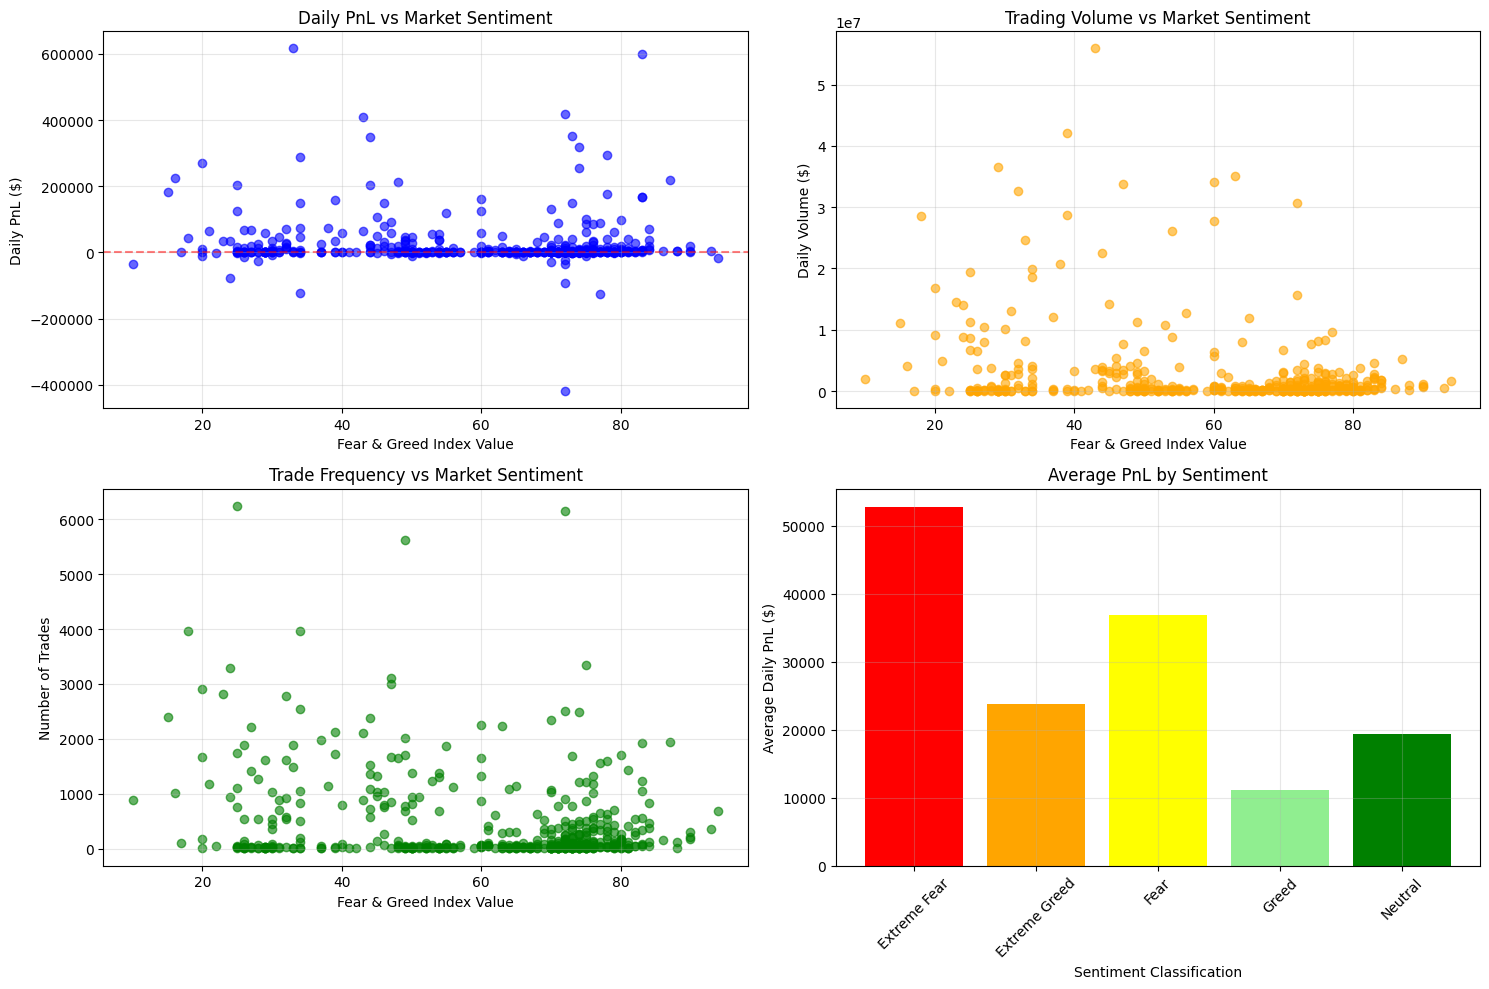

In [23]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))

# PnL vs Sentiment scatter plot
ax1.scatter(combined_data['value'], combined_data['total_pnl'], alpha=0.6, c='blue')
ax1.set_xlabel('Fear & Greed Index Value')
ax1.set_ylabel('Daily PnL ($)')
ax1.set_title('Daily PnL vs Market Sentiment')
ax1.axhline(y=0, color='red', linestyle='--', alpha=0.5)
ax1.grid(True, alpha=0.3)

# Volume vs Sentiment
ax2.scatter(combined_data['value'], combined_data['total_volume'], alpha=0.6, c='orange')
ax2.set_xlabel('Fear & Greed Index Value')
ax2.set_ylabel('Daily Volume ($)')
ax2.set_title('Trading Volume vs Market Sentiment')
ax2.grid(True, alpha=0.3)

# Trade Count vs Sentiment
ax3.scatter(combined_data['value'], combined_data['trade_count'], alpha=0.6, c='green')
ax3.set_xlabel('Fear & Greed Index Value')
ax3.set_ylabel('Number of Trades')
ax3.set_title('Trade Frequency vs Market Sentiment')
ax3.grid(True, alpha=0.3)

# PnL by sentiment classification
sentiment_avg_pnl = combined_data.groupby('classification')['total_pnl'].mean()
ax4.bar(sentiment_avg_pnl.index, sentiment_avg_pnl.values, color=['red', 'orange', 'yellow', 'lightgreen', 'green'])
ax4.set_xlabel('Sentiment Classification')
ax4.set_ylabel('Average Daily PnL ($)')
ax4.set_title('Average PnL by Sentiment')
ax4.tick_params(axis='x', rotation=45)
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/ds_Aakansh_Avasthi/outputs/sentiment_trading_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# **Sentiment Bucket Analysis Visualization**

/tmp/ipython-input-3783934223.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bucket_pnl = combined_data.groupby('sentiment_bucket')['total_pnl'].mean()
/tmp/ipython-input-3783934223.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bucket_volume = combined_data.groupby('sentiment_bucket')['total_volume'].mean()


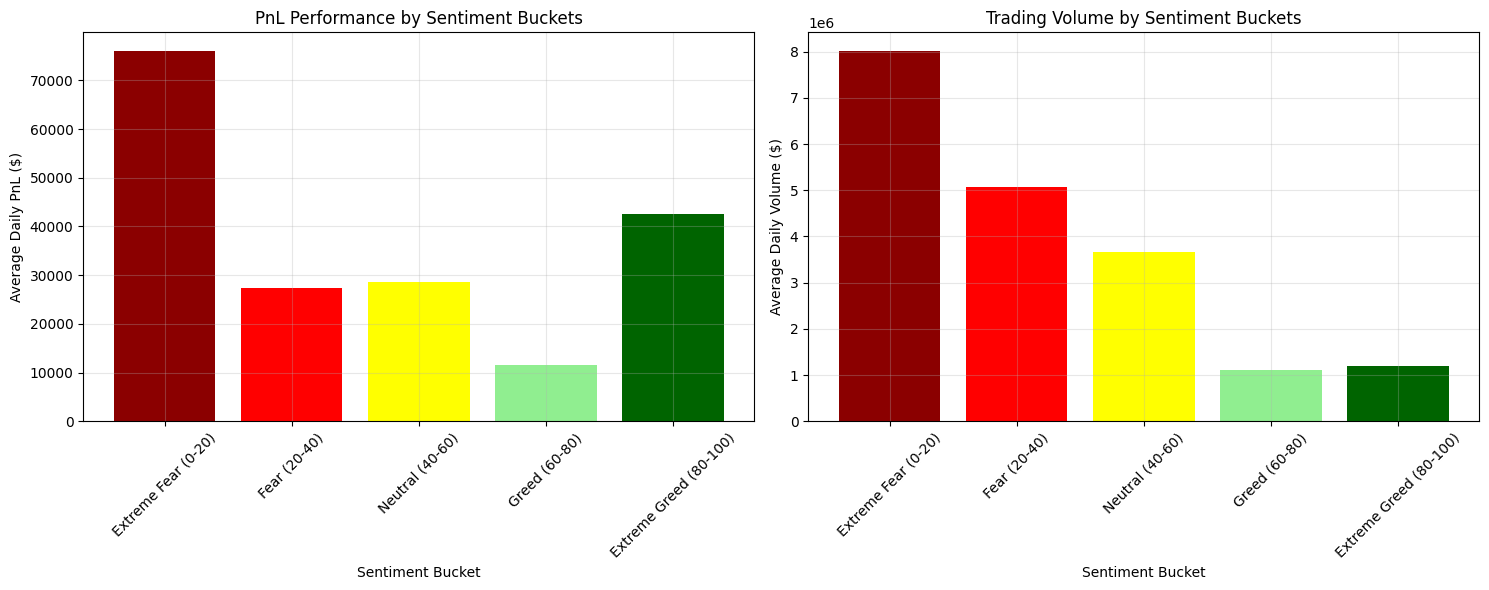

In [24]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

bucket_pnl = combined_data.groupby('sentiment_bucket')['total_pnl'].mean()
bucket_volume = combined_data.groupby('sentiment_bucket')['total_volume'].mean()

ax1.bar(range(len(bucket_pnl)), bucket_pnl.values, color=['darkred', 'red', 'yellow', 'lightgreen', 'darkgreen'])
ax1.set_xlabel('Sentiment Bucket')
ax1.set_ylabel('Average Daily PnL ($)')
ax1.set_title('PnL Performance by Sentiment Buckets')
ax1.set_xticks(range(len(bucket_pnl)))
ax1.set_xticklabels(bucket_pnl.index, rotation=45)
ax1.grid(True, alpha=0.3)

ax2.bar(range(len(bucket_volume)), bucket_volume.values, color=['darkred', 'red', 'yellow', 'lightgreen', 'darkgreen'])
ax2.set_xlabel('Sentiment Bucket')
ax2.set_ylabel('Average Daily Volume ($)')
ax2.set_title('Trading Volume by Sentiment Buckets')
ax2.set_xticks(range(len(bucket_volume)))
ax2.set_xticklabels(bucket_volume.index, rotation=45)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/ds_Aakansh_Avasthi/outputs/sentiment_buckets_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# **Time Series Analysis**

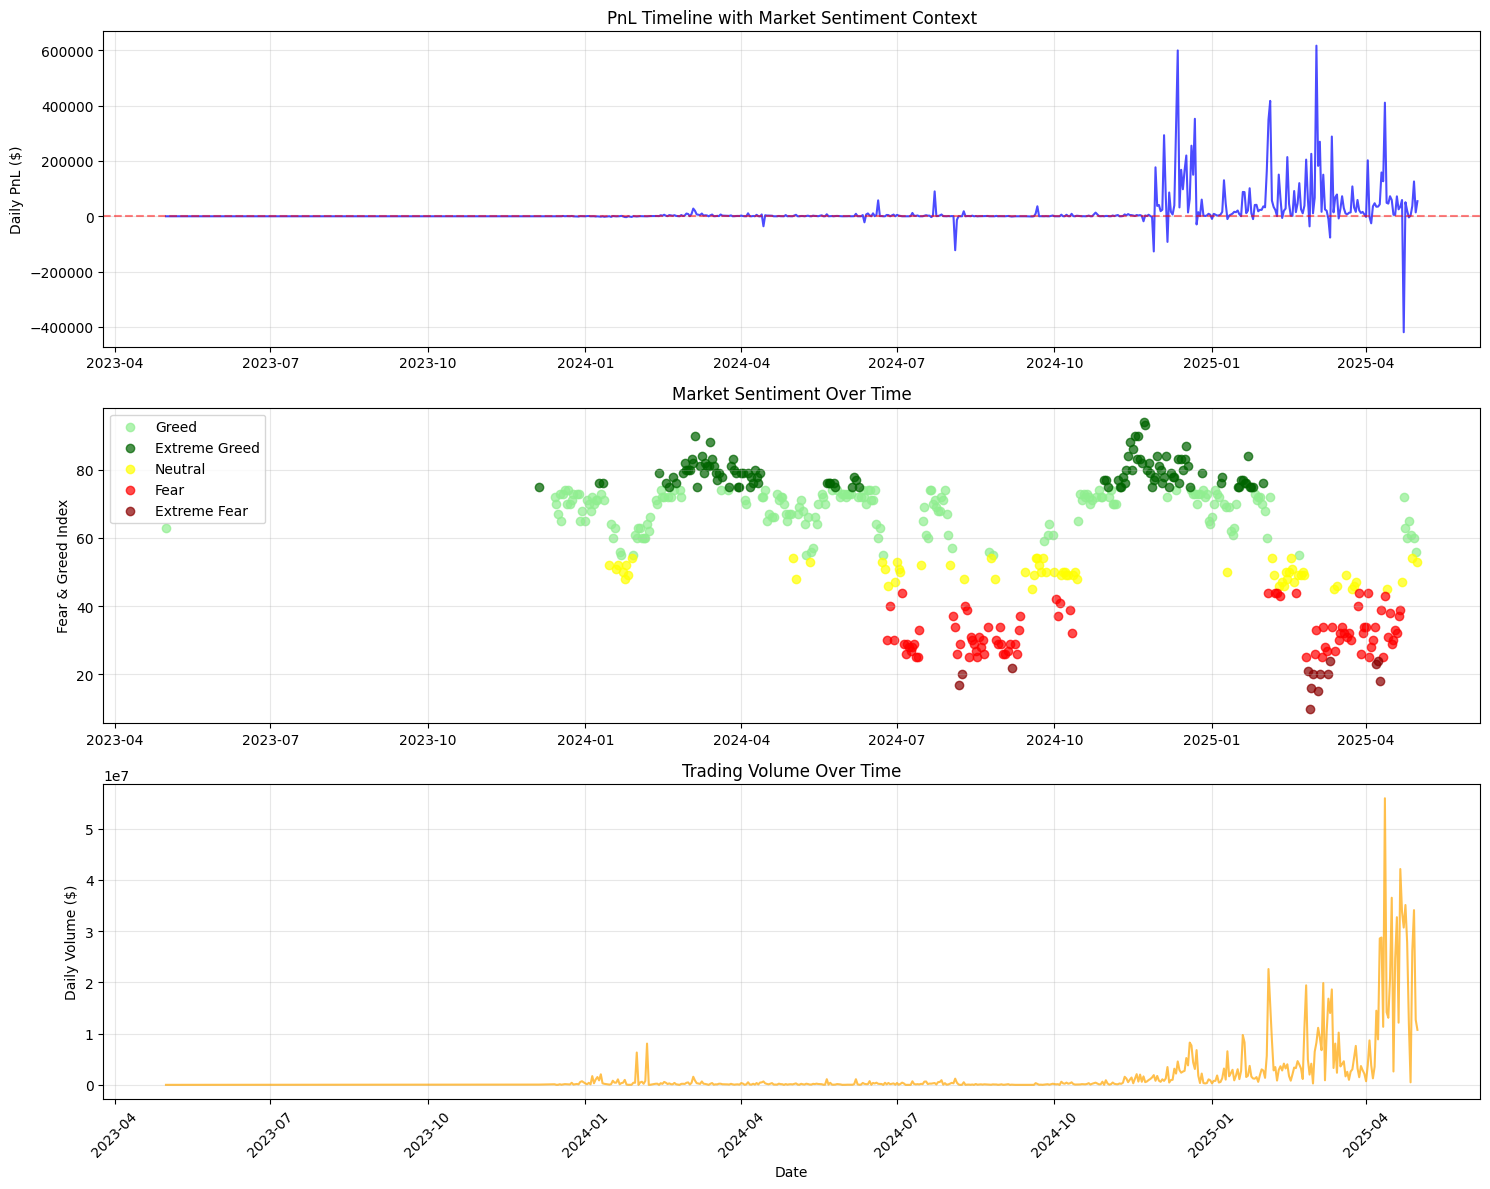

In [25]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(15, 12))

# PnL over time with sentiment background
ax1.plot(combined_data['date'], combined_data['total_pnl'], alpha=0.7, color='blue')
ax1.set_ylabel('Daily PnL ($)')
ax1.set_title('PnL Timeline with Market Sentiment Context')
ax1.axhline(y=0, color='red', linestyle='--', alpha=0.5)
ax1.grid(True, alpha=0.3)

# Sentiment over time
colors = {'Extreme Fear': 'darkred', 'Fear': 'red', 'Neutral': 'yellow', 'Greed': 'lightgreen', 'Extreme Greed': 'darkgreen'}
for sentiment in combined_data['classification'].unique():
    mask = combined_data['classification'] == sentiment
    ax2.scatter(combined_data[mask]['date'], combined_data[mask]['value'],
               c=colors[sentiment], label=sentiment, alpha=0.7)
ax2.set_ylabel('Fear & Greed Index')
ax2.set_title('Market Sentiment Over Time')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Volume over time
ax3.plot(combined_data['date'], combined_data['total_volume'], alpha=0.7, color='orange')
ax3.set_xlabel('Date')
ax3.set_ylabel('Daily Volume ($)')
ax3.set_title('Trading Volume Over Time')
ax3.grid(True, alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/ds_Aakansh_Avasthi/outputs/time_series_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# **Correlation Heatmap and Key Insights**

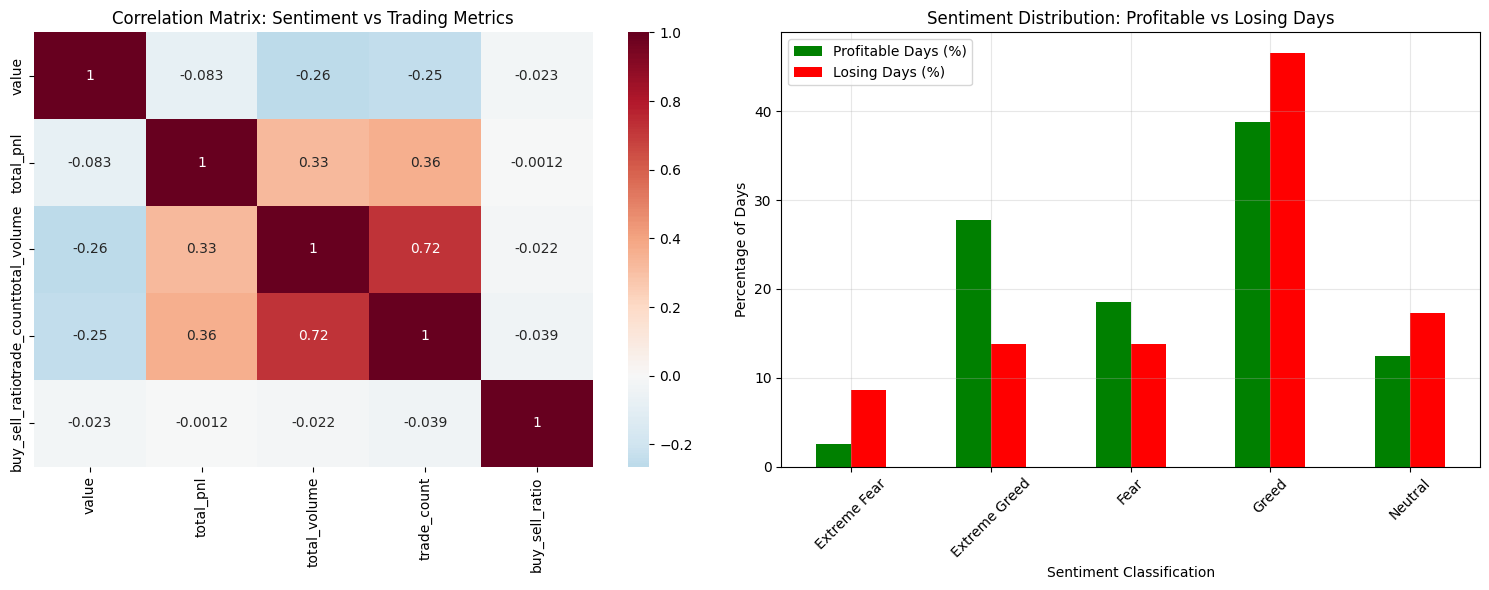

In [26]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

sns.heatmap(correlation_data, annot=True, cmap='RdBu_r', center=0, ax=ax1)
ax1.set_title('Correlation Matrix: Sentiment vs Trading Metrics')

# Profitable vs losing days sentiment distribution
profitable_sentiment = profitable_days['classification'].value_counts(normalize=True) * 100
losing_sentiment = losing_days['classification'].value_counts(normalize=True) * 100

comparison_data = pd.DataFrame({
    'Profitable Days (%)': profitable_sentiment,
    'Losing Days (%)': losing_sentiment
}).fillna(0)

comparison_data.plot(kind='bar', ax=ax2, color=['green', 'red'])
ax2.set_title('Sentiment Distribution: Profitable vs Losing Days')
ax2.set_xlabel('Sentiment Classification')
ax2.set_ylabel('Percentage of Days')
ax2.tick_params(axis='x', rotation=45)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/ds_Aakansh_Avasthi/outputs/correlation_insights.png', dpi=300, bbox_inches='tight')
plt.show()

# **Summary**

In [27]:
print("KEY FINDINGS SUMMARY")
print("=" * 50)
print(f"Dataset covers {len(combined_data)} trading days from May 2023 to May 2025")
print(f"Total PnL across all days: ${combined_data['total_pnl'].sum():,.2f}")
print(f"Success rate: {len(profitable_days)/len(combined_data)*100:.1f}% profitable days")

print("\nSentiment-Based Performance:")
print(f"- Extreme Fear days show highest avg PnL: ${extreme_fear_days['total_pnl'].mean():.2f}")
print(f"- Extreme Greed days avg PnL: ${extreme_greed_days['total_pnl'].mean():.2f}")
print(f"- Fear sentiment has {(combined_data['classification'] == 'Fear').sum()} days with avg PnL: ${combined_data[combined_data['classification'] == 'Fear']['total_pnl'].mean():.2f}")

print("\nKey Correlations:")
print(f"- Sentiment vs PnL correlation: {correlation_data.loc['value', 'total_pnl']:.3f}")
print(f"- Sentiment vs Volume correlation: {correlation_data.loc['value', 'total_volume']:.3f}")
print(f"- Volume vs PnL correlation: {correlation_data.loc['total_volume', 'total_pnl']:.3f}")

print(f"\nTrading Activity:")
print(f"- Higher sentiment = lower trading volume (correlation: {correlation_data.loc['value', 'total_volume']:.3f})")
print(f"- Average daily volume: ${combined_data['total_volume'].mean():,.2f}")
print(f"- Most active sentiment: {combined_data.groupby('classification')['trade_count'].mean().idxmax()}")

KEY FINDINGS SUMMARY
Dataset covers 479 trading days from May 2023 to May 2025
Total PnL across all days: $10,254,486.98
Success rate: 75.4% profitable days

Sentiment-Based Performance:
- Extreme Fear days show highest avg PnL: $76048.89
- Extreme Greed days avg PnL: $36198.45
- Fear sentiment has 91 days with avg PnL: $36891.82

Key Correlations:
- Sentiment vs PnL correlation: -0.083
- Sentiment vs Volume correlation: -0.264
- Volume vs PnL correlation: 0.326

Trading Activity:
- Higher sentiment = lower trading volume (correlation: -0.264)
- Average daily volume: $2,486,636.27
- Most active sentiment: Extreme Fear
